In [822]:
import pandas as pd 
import numpy as np
import statsmodels
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter 
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.metrics import brier_score_loss, make_scorer, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score, brier_score_loss, accuracy_score, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import KFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [742]:
data_path = "/Users/akirakuno/Downloads/CSSci/year2/Sem 4 projects/speeches_2014_2024_with_predictions.csv"

In [744]:
df = pd.read_csv(data_path) 

In [745]:
df.head() 

,file_id,speech_id,speaker_name,speaker_party,gender,speech_text,jaar,date,kamer,category,...,url,meta_url,vergadernummer,standardized_name,date_of_birth,seniority_days,coalition_status,word_count,ad_hominem_prediction,ad_hominem_label
0,h-tk-20152016-75-13-n1,SPEECH_4,De heer Bisschop,SGP,Man,Voorzitter. Wij helpen gaarne om het vaderland...,2015-2016,2016-04-12,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 75, item 13",bisschop,30-11-1956,1301.0,opposition,21.0,0,No AdHominem
1,h-tk-20152016-85-14,SPEECH_9,De heer Van Vliet,Van Vliet,Man,Voorzitter. De motie werd zo-even ontraden doo...,2015-2016,2016-05-19,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 85, item 14",van van vliet,25-11-1969,2164.0,opposition,43.0,0,No AdHominem
2,h-tk-20152016-66-9,SPEECH_20,De heer Ulenbelt,SP,Man,Voorzitter. Werkgevers kunnen zich verzekeren ...,2015-2016,2016-03-17,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 66, item 9",ulenbelt,04-01-1952,3396.0,opposition,72.0,0,No AdHominem
3,h-tk-20152016-66-9,SPEECH_22,De heer Ulenbelt,SP,Man,"Dat ben ik helemaal eens met de voorzitter, da...",2015-2016,2016-03-17,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 66, item 9",ulenbelt,04-01-1952,3396.0,opposition,555.0,0,No AdHominem
4,h-tk-20152016-66-9,SPEECH_23,Mevrouw Schut-Welkzijn,VVD,Woman,De heer Ulenbelt concludeert dat het UWV goedk...,2015-2016,2016-03-17,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 66, item 9",schut-welkzijn,06-02-1969,1275.0,coalition,19.0,1,AdHominem


In [746]:
# 1) 両列を datetime に変換
df['date'] = pd.to_datetime(df['date'])
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], dayfirst=True, errors='coerce')
# （dayfirst=True は例なので、必要に応じて “YYYY-MM-DD” の場合などは不要です）

# 2) 年齢を計算する関数を定義
def calculate_age(speech_date, birth_date):
    # speech_date と birth_date は pandas.Timestamp
    years = speech_date.year - birth_date.year
    # 誕生日がまだ来ていなければ 1 年引く
    if (speech_date.month, speech_date.day) < (birth_date.month, birth_date.day):
        years -= 1
    return years

# 3) apply を使って各行ごとに年齢を算出
df['age'] = df.apply(
    lambda row: calculate_age(row['date'], row['date_of_birth']),
    axis=1
)


In [747]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553851 entries, 0 to 553850
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   file_id                553851 non-null  object        
 1   speech_id              553851 non-null  object        
 2   speaker_name           553846 non-null  object        
 3   speaker_party          552161 non-null  object        
 4   gender                 553846 non-null  object        
 5   speech_text            553850 non-null  object        
 6   jaar                   553851 non-null  object        
 7   date                   553851 non-null  datetime64[ns]
 8   kamer                  553851 non-null  object        
 9   category               553851 non-null  object        
 10  title                  553851 non-null  object        
 11  document_number        0 non-null       float64       
 12  url                    553851 non-null  obje

In [748]:
df.isnull().sum() 

file_id                       0
speech_id                     0
speaker_name                  5
speaker_party              1690
gender                        5
speech_text                   1
jaar                          0
date                          0
kamer                         0
category                      0
title                         0
document_number          553851
url                           0
meta_url                      0
vergadernummer                0
standardized_name             5
date_of_birth              1503
seniority_days              407
coalition_status           1446
word_count                    1
ad_hominem_prediction         0
ad_hominem_label              0
age                        1503
dtype: int64

In [754]:
df2 = df.drop('document_number', axis = 1) 

In [756]:
df2.head() 

,file_id,speech_id,speaker_name,speaker_party,gender,speech_text,jaar,date,kamer,category,...,meta_url,vergadernummer,standardized_name,date_of_birth,seniority_days,coalition_status,word_count,ad_hominem_prediction,ad_hominem_label,age
0,h-tk-20152016-75-13-n1,SPEECH_4,De heer Bisschop,SGP,Man,Voorzitter. Wij helpen gaarne om het vaderland...,2015-2016,2016-04-12,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 75, item 13",bisschop,1956-11-30,1301.0,opposition,21.0,0,No AdHominem,59.0
1,h-tk-20152016-85-14,SPEECH_9,De heer Van Vliet,Van Vliet,Man,Voorzitter. De motie werd zo-even ontraden doo...,2015-2016,2016-05-19,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 85, item 14",van van vliet,1969-11-25,2164.0,opposition,43.0,0,No AdHominem,46.0
2,h-tk-20152016-66-9,SPEECH_20,De heer Ulenbelt,SP,Man,Voorzitter. Werkgevers kunnen zich verzekeren ...,2015-2016,2016-03-17,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 66, item 9",ulenbelt,1952-01-04,3396.0,opposition,72.0,0,No AdHominem,64.0
3,h-tk-20152016-66-9,SPEECH_22,De heer Ulenbelt,SP,Man,"Dat ben ik helemaal eens met de voorzitter, da...",2015-2016,2016-03-17,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 66, item 9",ulenbelt,1952-01-04,3396.0,opposition,555.0,0,No AdHominem,64.0
4,h-tk-20152016-66-9,SPEECH_23,Mevrouw Schut-Welkzijn,VVD,Woman,De heer Ulenbelt concludeert dat het UWV goedk...,2015-2016,2016-03-17,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 66, item 9",schut-welkzijn,1969-02-06,1275.0,coalition,19.0,1,AdHominem,47.0


In [758]:
df2.dropna() 

,file_id,speech_id,speaker_name,speaker_party,gender,speech_text,jaar,date,kamer,category,...,meta_url,vergadernummer,standardized_name,date_of_birth,seniority_days,coalition_status,word_count,ad_hominem_prediction,ad_hominem_label,age
0,h-tk-20152016-75-13-n1,SPEECH_4,De heer Bisschop,SGP,Man,Voorzitter. Wij helpen gaarne om het vaderland...,2015-2016,2016-04-12,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 75, item 13",bisschop,1956-11-30,1301.0,opposition,21.0,0,No AdHominem,59.0
1,h-tk-20152016-85-14,SPEECH_9,De heer Van Vliet,Van Vliet,Man,Voorzitter. De motie werd zo-even ontraden doo...,2015-2016,2016-05-19,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 85, item 14",van van vliet,1969-11-25,2164.0,opposition,43.0,0,No AdHominem,46.0
2,h-tk-20152016-66-9,SPEECH_20,De heer Ulenbelt,SP,Man,Voorzitter. Werkgevers kunnen zich verzekeren ...,2015-2016,2016-03-17,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 66, item 9",ulenbelt,1952-01-04,3396.0,opposition,72.0,0,No AdHominem,64.0
3,h-tk-20152016-66-9,SPEECH_22,De heer Ulenbelt,SP,Man,"Dat ben ik helemaal eens met de voorzitter, da...",2015-2016,2016-03-17,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 66, item 9",ulenbelt,1952-01-04,3396.0,opposition,555.0,0,No AdHominem,64.0
4,h-tk-20152016-66-9,SPEECH_23,Mevrouw Schut-Welkzijn,VVD,Woman,De heer Ulenbelt concludeert dat het UWV goedk...,2015-2016,2016-03-17,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 66, item 9",schut-welkzijn,1969-02-06,1275.0,coalition,19.0,1,AdHominem,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553846,h-tk-20232024-4-26,SPEECH_792490,Mevrouw Helder,BBB,Woman,"Voor de Handelingen, voorzitter: samenvoegen e...",2023-2024,2023-09-26,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 4, item 26",helder,1973-09-07,4850.0,opposition,7.0,0,No AdHominem,50.0
553847,h-tk-20232024-4-26,SPEECH_792491,Mevrouw Christine Teunissen,PvdD,Woman,Steun.,2023-2024,2023-09-26,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 4, item 26",christine teunissen,1985-09-06,1022.0,opposition,1.0,0,No AdHominem,38.0
553848,h-tk-20232024-4-26,SPEECH_792493,Mevrouw Mutluer,PvdA,Woman,En GroenLinks. Steun.,2023-2024,2023-09-26,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 4, item 26",mutluer,1979-12-11,1174.0,opposition,3.0,0,No AdHominem,43.0
553849,h-tk-20232024-4-26,SPEECH_792495,Mevrouw Hagen,D66,Woman,Ja. Die is er binnen vier dagen. Aangezien dit...,2023-2024,2023-09-26,tk,handelingen,...,https://zoek.officielebekendmakingen.nl/h-tk-2...,"nr. 4, item 26",hagen,1980-07-03,910.0,coalition,25.0,0,No AdHominem,43.0


In [760]:
df2.columns

Index(['file_id', 'speech_id', 'speaker_name', 'speaker_party', 'gender',
       'speech_text', 'jaar', 'date', 'kamer', 'category', 'title', 'url',
       'meta_url', 'vergadernummer', 'standardized_name', 'date_of_birth',
       'seniority_days', 'coalition_status', 'word_count',
       'ad_hominem_prediction', 'ad_hominem_label', 'age'],
      dtype='object')

In [762]:
df2['ad_hominem_prediction'].value_counts() 

ad_hominem_prediction
0    541456
1     12395
Name: count, dtype: int64

In [970]:
X = df2[['speaker_party', 'gender', 'seniority_days', 'coalition_status', 'word_count', 'age']] 

In [972]:
Y = df2[['ad_hominem_prediction']]

In [974]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [976]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)


In [978]:
categorical_cols = ['speaker_party', 'gender', 'coalition_status'] 
numeric_cols = ['seniority_days', 'word_count', 'age'] 


In [980]:
num_imputer = SimpleImputer(strategy='median') 

X_train_numeric = X_train[numeric_cols] 
X_train_numeric_imputed = pd.DataFrame(
    num_imputer.fit_transform(X_train_numeric),
    columns=numeric_cols,
    index=X_train.index
) 

X_test_numeric = X_test[numeric_cols]
X_test_numeric_imputed = pd.DataFrame(
    num_imputer.transform(X_test_numeric),
    columns=numeric_cols,
    index=X_test.index
)

In [982]:
X_train_pre = pd.concat(
    [X_train_numeric_imputed, X_train[categorical_cols]],
    axis=1
)
X_test_pre = pd.concat(
    [X_test_numeric_imputed, X_test[categorical_cols]],
    axis=1
)

In [985]:
X_train_encoded = pd.get_dummies(
    X_train_pre, 
    columns = categorical_cols, 
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test_pre, 
    columns = categorical_cols, 
    drop_first=True
)

X_test_encoded = X_test_encoded.reindex(
    columns = X_train_encoded.columns,
    fill_value = 0
)

In [961]:
model = LogisticRegression(max_iter=1000) 
model.fit(X_train_encoded, y_train)
y_pred = model.predict(X_test_encoded)  # No more “missing feature” errors


/Users/akirakuno/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/akirakuno/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [962]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 0]) 

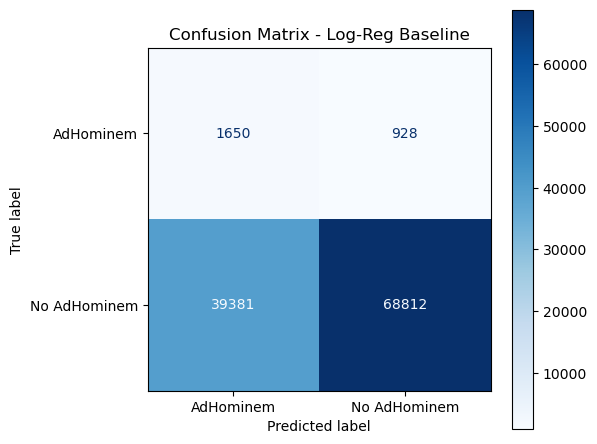

In [882]:
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels    = ['AdHominem', 'No AdHominem']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_title('Confusion Matrix - Log-Reg Baseline')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.show()


The confusion matrix above shows that the model is way too unbalanced. 

In [861]:
smote = SMOTE(random_state = 42) 
X_train_res, y_train_res = smote.fit_resample(X_train_encoded, y_train) 

In [886]:
model = LogisticRegression(class_weight = 'balanced', max_iter = 1000) 
model.fit(X_train_res, y_train_res)
y_pred_smote = model.predict(X_test_encoded)

/Users/akirakuno/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/akirakuno/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [888]:
accuracy = accuracy_score(y_test, y_pred_smote)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.9328


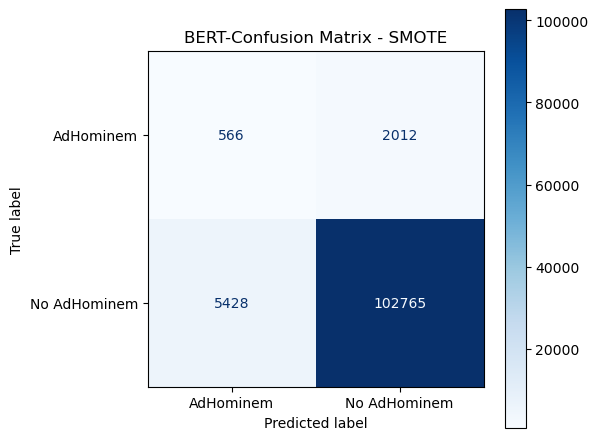

In [890]:
cm = confusion_matrix(y_test, y_pred_smote, labels=[1, 0]) 
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels    = ['AdHominem', 'No AdHominem']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_title('BERT-Confusion Matrix - SMOTE')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.show()


In [892]:
print(classification_report(y_test, y_pred_smote, digits=2)) 

              precision    recall  f1-score   support

           0       0.98      0.95      0.97    108193
           1       0.09      0.22      0.13      2578

    accuracy                           0.93    110771
   macro avg       0.54      0.58      0.55    110771
weighted avg       0.96      0.93      0.95    110771



In [847]:
ros = RandomOverSampler(random_state = 42) 
X_train_ros, y_train_ros = ros.fit_resample(X_train_encoded, y_train) 

In [849]:
model = LogisticRegression(max_iter = 1000) 
model.fit(X_train_ros, y_train_ros)
y_pred_ros = model.predict(X_test_encoded)

/Users/akirakuno/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/akirakuno/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [851]:
accuracy = accuracy_score(y_test, y_pred_ros)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.6361


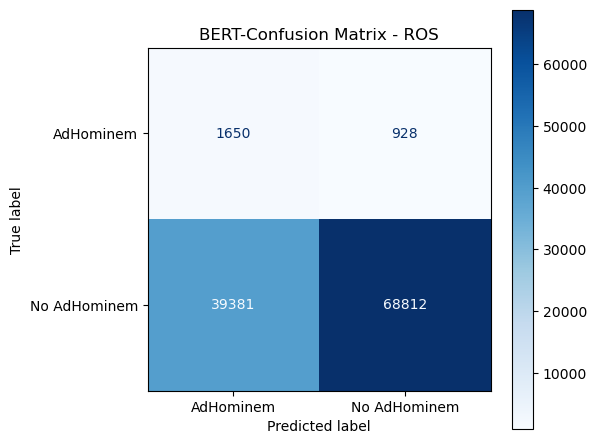

In [871]:
cm = confusion_matrix(y_test, y_pred_ros, labels=[1, 0]) 
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels    = ['AdHominem', 'No AdHominem']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_title('BERT-Confusion Matrix - ROS')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.show()


In [873]:
print(classification_report(y_test, y_pred_ros, digits=2)) 

              precision    recall  f1-score   support

           0       0.99      0.64      0.77    108193
           1       0.04      0.64      0.08      2578

    accuracy                           0.64    110771
   macro avg       0.51      0.64      0.42    110771
weighted avg       0.96      0.64      0.76    110771



In [876]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [894]:
# Define an Random Forest object using RandomForestClassifier 
rf_model = RandomForestClassifier(n_estimators=100, max_features='sqrt', class_weight = 'balanced', random_state=42)

# Fit the model
rf_model.fit(X_train_encoded, y_train)
y_pred_rf = rf_model.predict(X_test_encoded) 
accuracy = accuracy_score(y_test, y_pred_rf) 
print(accuracy) 
print(classification_report(y_test, y_pred_rf, digits=2)) 

/Users/akirakuno/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.9591048198535718
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    108193
           1       0.17      0.20      0.18      2578

    accuracy                           0.96    110771
   macro avg       0.58      0.59      0.58    110771
weighted avg       0.96      0.96      0.96    110771



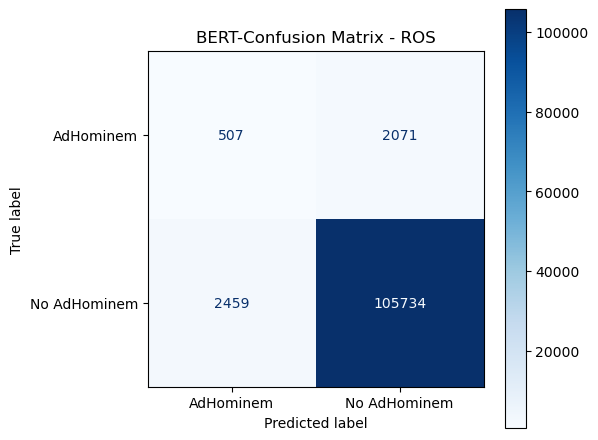

In [896]:
cm = confusion_matrix(y_test, y_pred_rf, labels=[1, 0]) 
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels    = ['AdHominem', 'No AdHominem']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_title('BERT-Confusion Matrix - ROS')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.show()

In [992]:
from imblearn.combine import SMOTEENN
sampler = SMOTEENN(random_state = 42, sampling_strategy = 0.5) 

X_train_smoteenn, y_train_smoteenn = sampler.fit_resample(X_train_encoded, y_train) 
clf = RandomForestClassifier(
        n_estimators=200, 
        random_state=42, 
        class_weight=None 
) 

clf.fit(X_train_smoteenn, y_train_smoteenn) 
y_pred = clf.predict(X_test_encoded) 
accuracy = accuracy_score(y_test, y_pred) 
print(accuracy) 
print(classification_report(y_test, y_pred, digits=2)) 

/Users/akirakuno/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.9603777161892553
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    108193
           1       0.19      0.21      0.20      2578

    accuracy                           0.96    110771
   macro avg       0.58      0.59      0.59    110771
weighted avg       0.96      0.96      0.96    110771



Smote + randomForest model is the best interms of balance between two classes (highest F1 value) 

In [993]:
import xgboost as xgb 
sampler = SMOTEENN(random_state = 42, sampling_strategy = 0.5) 
X_train_smoteenn, y_train_smoteenn = sampler.fit_resample(X_train_encoded, y_train) 
ratio = (y_train==0).sum() / (y_train==1).sum()
xgb_clf = xgb.XGBClassifier(
        objective='binary:logistic', 
        use_label_encoder=False, 
        eval_metric='logloss', 
        scales_pos_weifht=ratio, 
        random_state=42
) 

xgb_clf.fit(X_train_smoteenn, y_train_smoteenn) 
print(classification_report(y_test, xgb_clf.predict(X_test_encoded), digits = 2))

/Users/akirakuno/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [04:54:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "scales_pos_weifht", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.98      0.98      0.98    108193
           1       0.21      0.21      0.21      2578

    accuracy                           0.96    110771
   macro avg       0.59      0.60      0.60    110771
weighted avg       0.96      0.96      0.96    110771



In [998]:
feature_names = X_train_encoded.columns.tolist() 
importances = xgb_clf.feature_importances_
df_imp = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)


print(df_imp.head(10))

                          feature  importance
45              speaker_party_VVD    0.086394
53    coalition_status_opposition    0.077448
1                      word_count    0.059744
39              speaker_party_NSC    0.055278
9               speaker_party_D66    0.044441
10             speaker_party_DENK    0.041671
7               speaker_party_CDA    0.041524
41             speaker_party_PvdA    0.039011
8                speaker_party_CU    0.037445
26  speaker_party_GroenLinks-PvdA    0.036797


In [149]:
preproc_fitted = clf_pipeline.named_steps['preprocessor']
ohe_pipeline   = preproc_fitted.named_transformers_['cat']  
ohe_encoder    = ohe_pipeline.named_steps['onehot'] 

In [151]:
ohe_feature_names = ohe_encoder.get_feature_names_out(categorical_cols)


In [153]:
feature_names = numeric_cols + list(ohe_feature_names)

In [155]:
model = clf_pipeline.named_steps['classifier']
coefs = model.coef_[0]  # shape = (n_features,)

import pandas as pd
df_importance = pd.DataFrame({
    'feature':    feature_names,
    'coef':       coefs,
    'abs_coef':   abs(coefs)
})
df_importance = df_importance.sort_values(by='abs_coef', ascending=False)


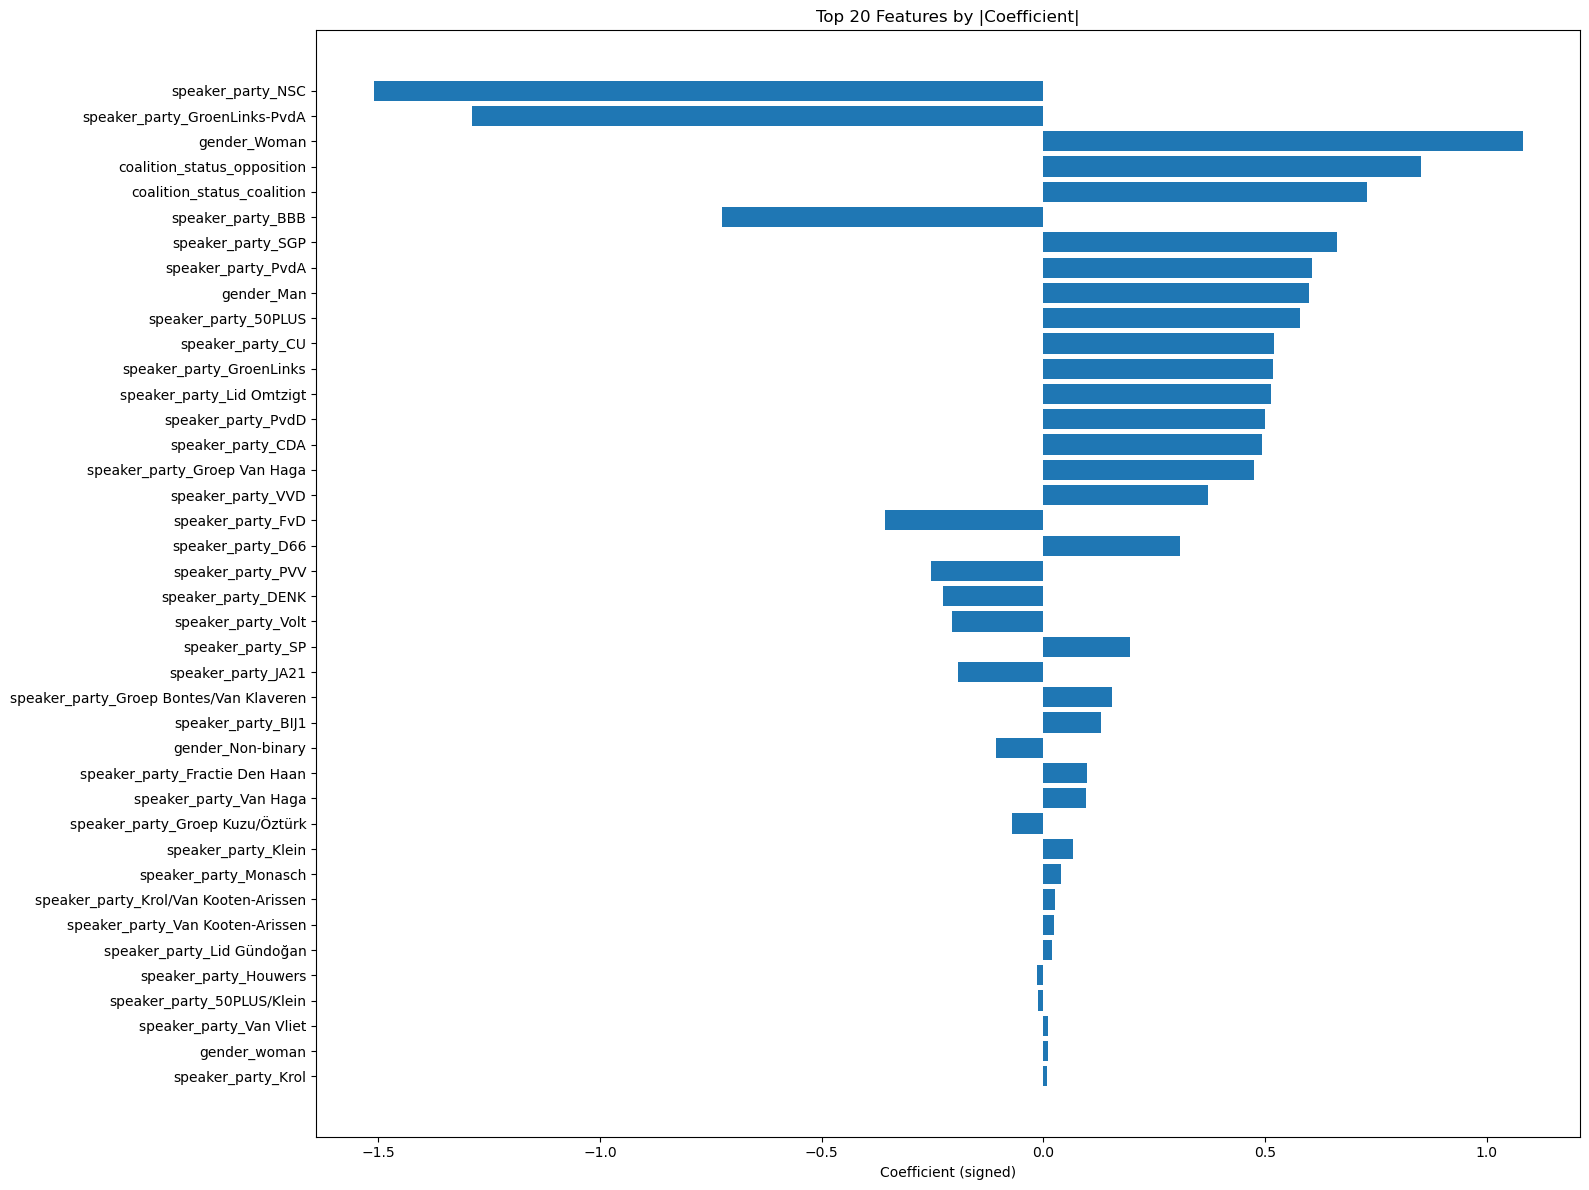

In [161]:
import matplotlib.pyplot as plt

topn = df_importance.head(40)

plt.figure(figsize=(16, 12))
plt.barh(topn['feature'], topn['coef'])
plt.xlabel('Coefficient (signed)')
plt.title('Top 20 Features by |Coefficient|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Part 2: Time series analysis 

In [477]:
df['jaar'].value_counts() 

jaar
2018-2019    64794
2023-2024    60893
2015-2016    59257
2017-2018    59016
2022-2023    57972
2019-2020    56979
2014-2015    53253
2021-2022    51089
2020-2021    47482
2016-2017    43116
Name: count, dtype: int64

In [485]:
df['ad_hominem_prediction'].dtype 

dtype('int64')

In [516]:

df_hom1 = df[df['ad_hominem_prediction'] == 1]

df_hom1 = df_hom1[['date', 'jaar', 'ad_hominem_prediction']].copy()

df_hom1 = df_hom1.reset_index(drop=True)


print(df_hom1.head())


         date       jaar  ad_hominem_prediction
0  2016-03-17  2015-2016                      1
1  2015-10-14  2015-2016                      1
2  2015-10-14  2015-2016                      1
3  2015-10-14  2015-2016                      1
4  2015-10-14  2015-2016                      1


In [518]:
df_hom1['date'] = pd.to_datetime(df_hom1['date']) 

In [520]:
df_hom1 = df_hom1.set_index('date') 

monthly_count = df_hom1['ad_hominem_prediction'].resample('M').count() 
print(monthly_count.head()) 

date
2014-09-30     64
2014-10-31     89
2014-11-30    172
2014-12-31     59
2015-01-31     51
Freq: ME, Name: ad_hominem_prediction, dtype: int64


/var/folders/kn/208w6lyn7d3gzc9jp41pk7b00000gn/T/ipykernel_14850/806044947.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_count = df_hom1['ad_hominem_prediction'].resample('M').count()


In [550]:
df_hom1['monthly_count'] = monthly_count 

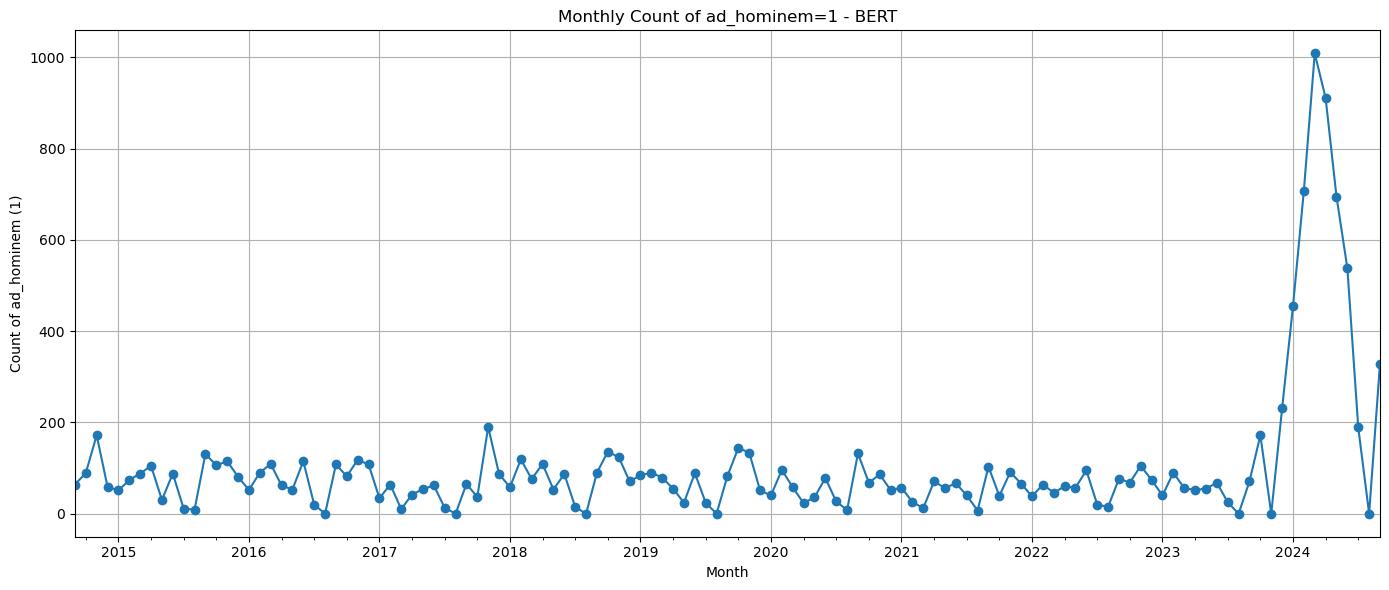

In [533]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
monthly_count.plot(marker='o', linestyle='-')
plt.title('Monthly Count of ad_hominem=1 - BERT')
plt.xlabel('Month')
plt.ylabel('Count of ad_hominem (1)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [580]:
monthly_count.head() 

date
2014-09-30     64
2014-10-31     89
2014-11-30    172
2014-12-31     59
2015-01-31     51
Freq: ME, Name: ad_hominem_prediction, dtype: int64

In [582]:
from statsmodels.tsa.stattools import adfuller 
adf_result = adfuller(monthly_count.dropna())

adf_output = pd.Series(adf_result[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in adf_result[4].items():
    adf_output[f'Critical Value ({key})'] = value

adf_output

Test Statistic                   0.330661
p-value                          0.978708
#Lags Used                      12.000000
Number of Observations Used    108.000000
Critical Value (1%)             -3.492401
Critical Value (5%)             -2.888697
Critical Value (10%)            -2.581255
dtype: float64

Based on the Augmented Dickey Fuller test, p-value being almost 1 and test statistic value being nowhere near any of the critical value, which means that this time series appears non-stationary.

Consequently, the current series needs to be transformed in order to proceed with further analysis. 

In [639]:
df_monthly = monthly_counts.reset_index(name='count_1')

In [641]:
df_monthly.head() 

,date,count_1
0,2014-09-30,64
1,2014-10-31,89
2,2014-11-30,172
3,2014-12-31,59
4,2015-01-31,51


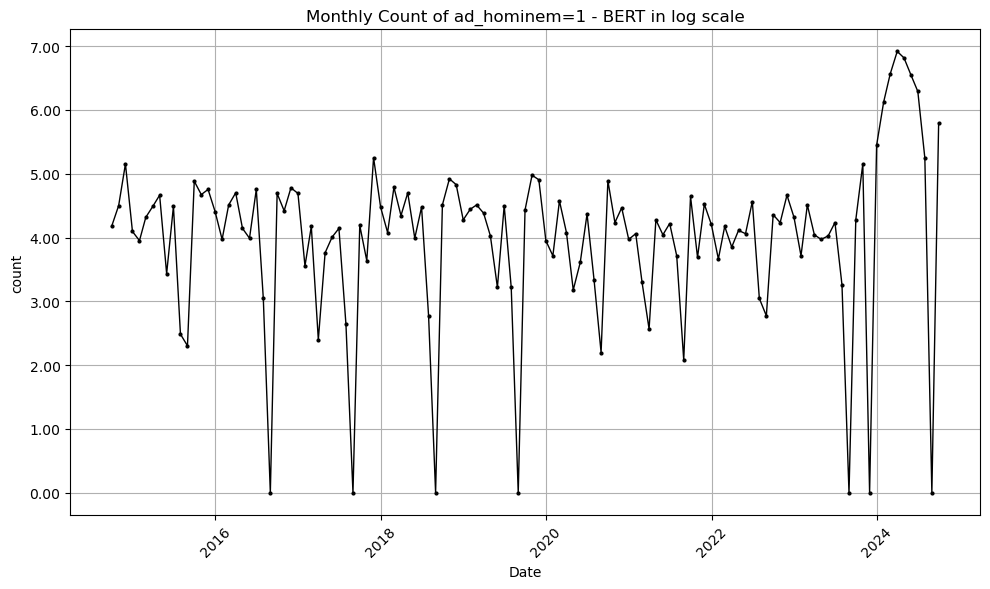

In [643]:
df_monthly['log_count_1'] = np.log(df_monthly['count_1'] + 1)
# Plot the time series data
plt.figure(figsize=(10, 6))
plt.plot(df_monthly['date'], df_monthly['log_count_1'], marker='o', linestyle='-', color='black',markersize = 2,linewidth=1)
plt.title('Monthly Count of ad_hominem=1 - BERT in log scale')
plt.xlabel('Date')
plt.ylabel('count')
plt.grid(True)
# Manually format y-axis labels to avoid scientific notation
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.2f}'.format(x)))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Above is the count of speeches that were flagged as ad-hominem attacks on monthly basis in log scale, as you can see, some part of the line are incontinuous, due to the fact that there were a couple of months when the ad-hominem attacks didn't happen in the parliament. 

In [646]:
from statsmodels.tsa.stattools import adfuller 
adf_result = adfuller(df_monthly['log_count_1'].dropna())

adf_output = pd.Series(adf_result[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in adf_result[4].items():
    adf_output[f'Critical Value ({key})'] = value

adf_output

Test Statistic                  -1.414841
p-value                          0.575141
#Lags Used                      13.000000
Number of Observations Used    107.000000
Critical Value (1%)             -3.492996
Critical Value (5%)             -2.888955
Critical Value (10%)            -2.581393
dtype: float64

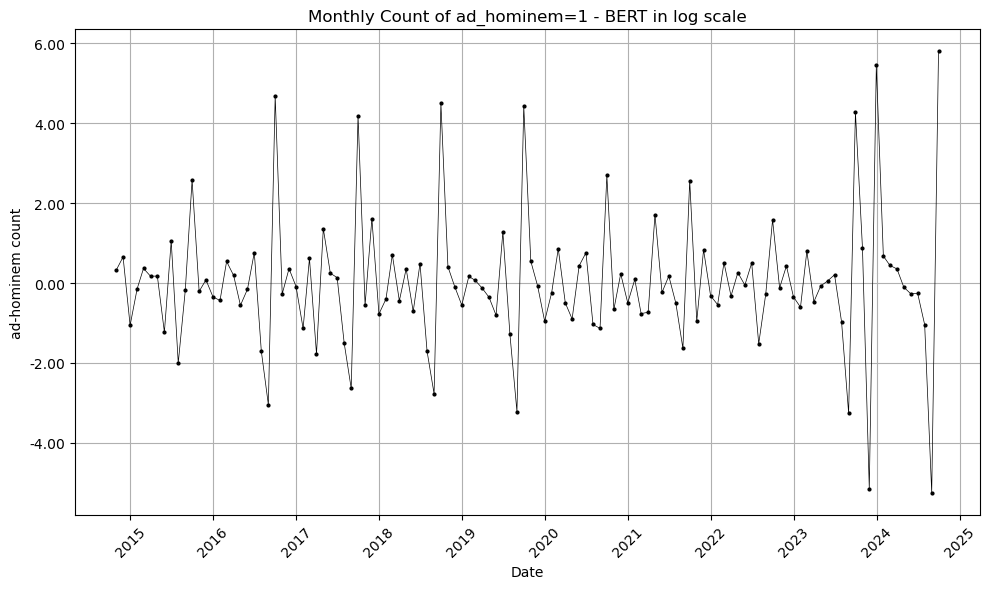

In [648]:

df_monthly['log_count_diff'] = df_monthly['log_count_1'].diff()



# Plotting the first difference of the log-transformed series
plt.figure(figsize=(10, 6))
plt.plot(df_monthly['date'], df_monthly['log_count_diff'], marker='o', linestyle='-', color='black', markersize=2,linewidth=0.5)
plt.title('Monthly Count of ad_hominem=1 - BERT in log scale')
plt.xlabel('Date')
plt.ylabel('ad-hominem count')
plt.grid(True)
# Manually format y-axis labels to avoid scientific notation
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.2f}'.format(x)))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [650]:

from statsmodels.tsa.stattools import adfuller 
adf_result = adfuller(df_monthly['log_count_diff'].dropna())

adf_output = pd.Series(adf_result[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in adf_result[4].items():
    adf_output[f'Critical Value ({key})'] = value

adf_output

Test Statistic                -1.223210e+01
p-value                        1.047964e-22
#Lags Used                     1.000000e+01
Number of Observations Used    1.090000e+02
Critical Value (1%)           -3.491818e+00
Critical Value (5%)           -2.888444e+00
Critical Value (10%)          -2.581120e+00
dtype: float64

In [678]:
from pmdarima import auto_arima 
model = auto_arima(df_monthly['log_count_1'], start_p=0, start_q=0,
                   test='adf',       # Use adf test to find optimal 'd'
                   max_p=5, max_q=5, # Maximum p and q
                   m=1,              # Frequency of the series
                   d=1,           # Let the model determine 'd'
                   seasonal=False,   # No Seasonality
                   start_P=0, 
                   D=0, 
                   trace=True,
                   error_action='ignore',  
                   suppress_warnings=True, 
                   stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=470.410, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=453.304, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=468.418, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=436.550, Time=0.02 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=436.663, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.04 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=434.552, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=451.304, Time=0.00 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=434.665, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=inf, Time=0.04 sec

Best mode

In [687]:
# Extract the selected model order
order = model.order


model = ARIMA(df_monthly['log_count_1'], order=order)
model_fit = model.fit()

forecast = model_fit.get_forecast(steps=12)

/var/folders/kn/208w6lyn7d3gzc9jp41pk7b00000gn/T/ipykernel_14850/2012471257.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=df_monthly['date'].iloc[-1] + pd.Timedelta(days=1), periods=12, freq = 'M')


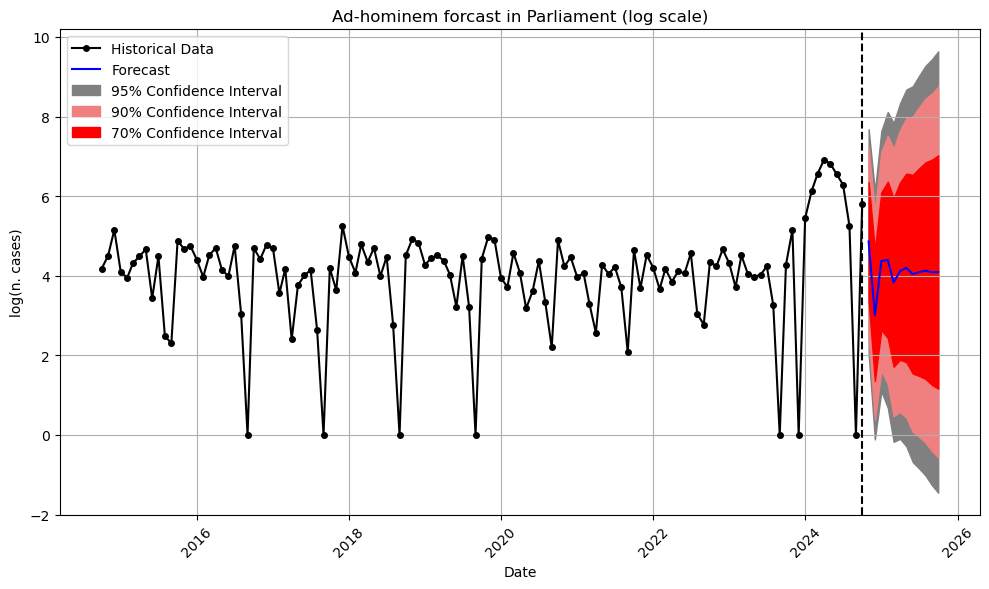

In [695]:
#Extract the forecast mean and confidence intervals
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha = 0.05) # 95% confidence interval

# Calculate the 70% and 90% confidence intervals
conf_int_70 = forecast.conf_int(alpha = 0.3)  # 70% confidence interval
conf_int_90 = forecast.conf_int(alpha = 0.1)  # 90% confidence interval

# Convert forecast index to match the dates if necessary
forecast_dates = pd.date_range(start=df_monthly['date'].iloc[-1] + pd.Timedelta(days=1), periods=12, freq = 'M')


# Plot the historical data
plt.figure(figsize=(10, 6))
plt.plot(df_monthly['date'], df_monthly['log_count_1'], marker='o', linestyle='-', color='black', markersize=4, label='Historical Data')

# Plot the forecast
plt.plot(forecast_dates, forecast_mean, color='blue', label='Forecast')

# Plot the confidence intervals
plt.fill_between(forecast_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='grey', alpha=1, label='95% Confidence Interval')
plt.fill_between(forecast_dates, conf_int_90.iloc[:, 0], conf_int_90.iloc[:, 1], color='lightcoral', alpha=1, label='90% Confidence Interval')
plt.fill_between(forecast_dates, conf_int_70.iloc[:, 0], conf_int_70.iloc[:, 1], color='red', alpha=1, label='70% Confidence Interval')

# Delineate the start of the forecast with a solid black line
plt.axvline(x=df_monthly['date'].iloc[-1], color='black', linestyle='--')

plt.title('Ad-hominem forcast in Dutch parliament (log scale)')
plt.xlabel('Date')
plt.ylabel('log(n. cases)')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()